In [5]:
import numpy as np
import matplotlib.pyplot as plt

g, l, m = 9.81, 1.0, 1.0
omega = np.sqrt(g / l)
T = 2 * np.pi / omega
y0 = np.array([0.1, 0.0])
periods = 5
steps_per_period = [50, 100, 200]


def rhs(y):
    theta, v = y
    return np.array([v, -omega**2 * theta])


def exact(t):
    theta0, v0 = y0
    theta = theta0 * np.cos(omega*t) + v0/omega * np.sin(omega*t)
    v = -omega*theta0 * np.sin(omega*t) + v0 * np.cos(omega*t)
    return np.column_stack((theta, v))


def energy(y):
    U = 0.5 * m * g * l * y[:, 0]**2
    K = 0.5 * m * l**2 * y[:, 1]**2
    return U, K


In [6]:
def solve(method, n_per_period):
    n_steps = periods * n_per_period
    h = T / n_per_period
    t = np.arange(n_steps + 1) * h
    y = np.empty((n_steps + 1, 2))
    y[0] = y0
    for n in range(n_steps):
        if method == "Эйлер":
            y[n + 1] = y[n] + h * rhs(y[n])
        elif method == "RK4":
            k1 = rhs(y[n])
            k2 = rhs(y[n] + h*k1/2)
            k3 = rhs(y[n] + h*k2/2)
            k4 = rhs(y[n] + h*k3)
            y[n + 1] = y[n] + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        else:
            raise ValueError("Неизвестный метод")
    return t, y

results = {(method, n): solve(method, n)
           for method in ["Эйлер", "RK4"] for n in steps_per_period}


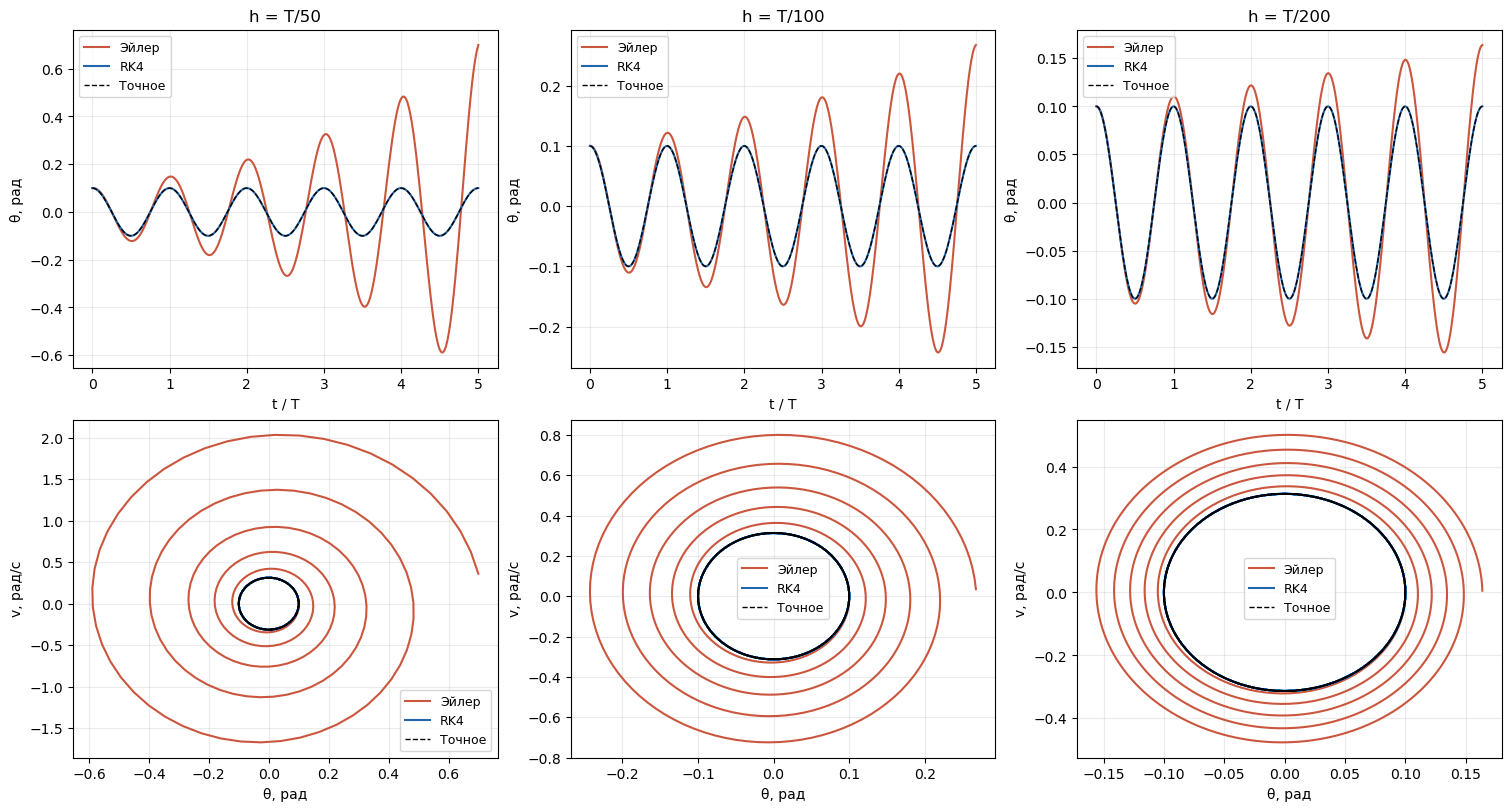

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
t_fine = np.linspace(0, periods*T, 4001)
y_fine = exact(t_fine)
colors = {"Эйлер": "#cb563e", "RK4": "#2166ac"}
for col, n in enumerate(steps_per_period):
    for method in ["Эйлер", "RK4"]:
        t, y = results[method, n]
        axes[0, col].plot(t/T, y[:, 0], color=colors[method], label=method)
        axes[1, col].plot(y[:, 0], y[:, 1], color=colors[method], label=method)
    axes[0, col].plot(t_fine/T, y_fine[:, 0], "k--", lw=1, label="Точное")
    axes[1, col].plot(y_fine[:, 0], y_fine[:, 1], "k--", lw=1, label="Точное")
    axes[0, col].set(title=f"h = T/{n}", xlabel="t / T", ylabel="θ, рад")
    axes[1, col].set(xlabel="θ, рад", ylabel="v, рад/с")
for ax in axes.flat:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
plt.show()


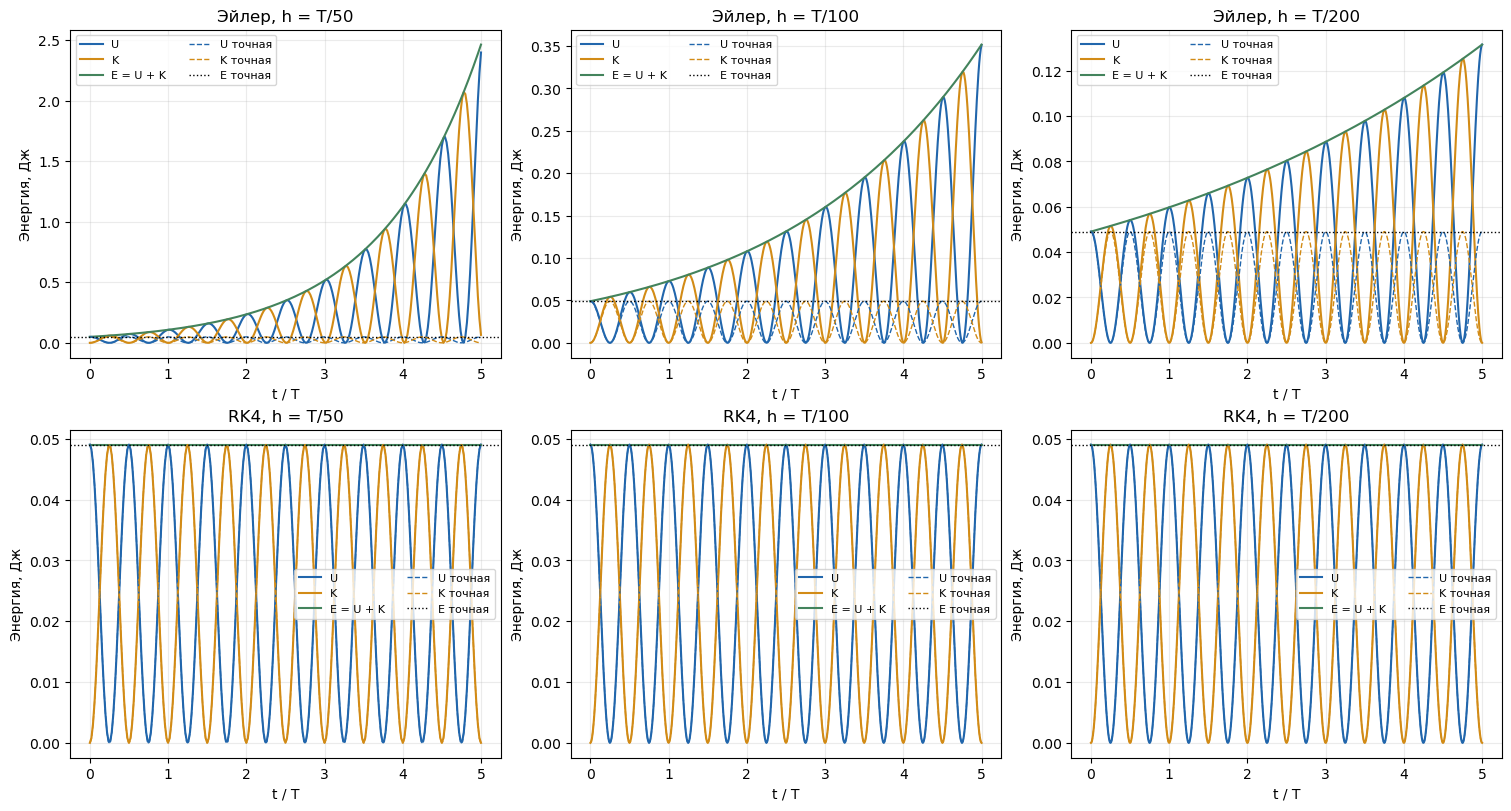

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
U_fine, K_fine = energy(y_fine)
E0 = float(sum(energy(y0.reshape(1, 2)))[0])
for row, method in enumerate(["Эйлер", "RK4"]):
    for col, n in enumerate(steps_per_period):
        ax = axes[row, col]
        t, y = results[method, n]
        U, K = energy(y)
        ax.plot(t/T, U, color="#2166ac", label="U")
        ax.plot(t/T, K, color="#d28b16", label="K")
        ax.plot(t/T, U+K, color="#43835c", label="E = U + K")
        ax.plot(t_fine/T, U_fine, "--", color="#2166ac", lw=1, label="U точная")
        ax.plot(t_fine/T, K_fine, "--", color="#d28b16", lw=1, label="K точная")
        ax.axhline(E0, color="black", ls=":", lw=1, label="E точная")
        ax.set(title=f"{method}, h = T/{n}", xlabel="t / T", ylabel="Энергия, Дж")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, ncol=2)
plt.show()


Период T = 2.00606668 с; время расчёта = 10.03033340 с
Метод           h, с       max |Δθ|   Ошибка сост.          ΔE/E0
Эйлер      0.0401213   5.993765e-01   6.104236e-01   4.924923e+01
Эйлер      0.0200607   1.675581e-01   1.679215e-01   6.170926e+00
Эйлер      0.0100303   6.375210e-02   6.377454e-02   1.681761e+00
RK4        0.0401213   6.218303e-06   6.527375e-06  -1.364601e-05
RK4        0.0200607   3.884044e-07   4.080102e-07  -4.270731e-07
RK4        0.0100303   2.426102e-08   2.550139e-08  -1.335098e-08


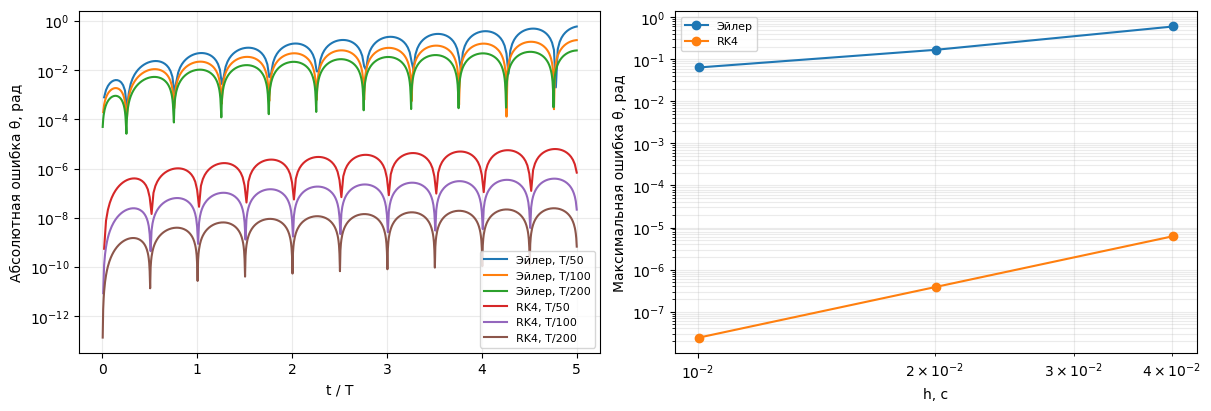

In [10]:
print(f"Период T = {T:.8f} с; время расчёта = {periods*T:.8f} с")
print(f"{'Метод':<8} {'h, с':>11} {'max |Δθ|':>14} {'Ошибка сост.':>14} {'ΔE/E0':>14}")
errors = {}
for method in ["Эйлер", "RK4"]:
    errors[method] = []
    for n in steps_per_period:
        t, y = results[method, n]
        diff = y - exact(t)
        angle_error = np.max(np.abs(diff[:, 0]))
        state_error = np.max(np.sqrt(diff[:, 0]**2 + (diff[:, 1]/omega)**2))
        U, K = energy(y)
        drift = (U[-1] + K[-1] - E0) / E0
        errors[method].append(angle_error)
        print(f"{method:<8} {T/n:11.7f} {angle_error:14.6e} {state_error:14.6e} {drift:14.6e}")
    ratios = np.array(errors[method][:-1]) / errors[method][1:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for method in ["Эйлер", "RK4"]:
    for n in steps_per_period:
        t, y = results[method, n]
        error = np.abs(y[:, 0] - exact(t)[:, 0])
        axes[0].semilogy(t/T, np.where(error > 0, error, np.nan),
                         label=f"{method}, T/{n}")
    axes[1].loglog(T/np.array(steps_per_period), errors[method], "o-", label=method)
axes[0].set(xlabel="t / T", ylabel="Абсолютная ошибка θ, рад")
axes[1].set(xlabel="h, с", ylabel="Максимальная ошибка θ, рад")
for ax in axes:
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8)
plt.show()
